# Proyecto 2 — Modelo de Clasificación
## Predicción de Desempeño Bajo el Promedio Departamental — Huila

**Pregunta de negocio:** 

> ¿Un estudiante estará por debajo del promedio departamental dado su perfil socioeconómico y municipio?


**Responsable** Gabriel Juan De Dios

**Rol** Ciencia de Datos / Despliegue del tablero

**Tipo de modelo** Modelo de clasificación binaria

**Variable objetivo** desempeno_bajo (1 = bajo el promedio departamental, 0 = igual o sobre el promedio)  

**Cliente** Secretaría de Educación del Huila

---
## 1. Librerías - Carga de datos

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Preprocesamiento y métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

# Construcción de redes neuronales
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Registro de experimentos y serialización
import mlflow
import mlflow.keras
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Semillas fijas para garantizar reproducibilidad entre ejecuciones
tf.random.set_seed(42)
np.random.seed(42)

In [2]:
# Carga del conjunto de datos depurado en el Proyecto 1
# El archivo corresponde al subconjunto filtrado para el departamento del Huila
df = pd.read_csv('../tarea2_datos/Datos_Huila_Limpio.csv')

print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (111556, 19)


,periodo,municipio,naturaleza_colegio,area_colegio,jornada,calendario,enfoque_colegio,genero,estrato,educacion_madre,educacion_padre,tiene_internet,tiene_computador,puntaje_matematicas,puntaje_lectura,puntaje_sociales,puntaje_ciencias,puntaje_ingles,puntaje_global
0,20194,AIPE,OFICIAL,RURAL,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 2,Postgrado,Primaria completa,Si,Si,66.0,69.0,70.0,65.0,71.0,339.0
1,20194,AIPE,OFICIAL,RURAL,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 2,Postgrado,Primaria completa,Si,Si,66.0,69.0,70.0,65.0,71.0,339.0
2,20194,LA PLATA,OFICIAL,URBANO,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 1,Primaria incompleta,Primaria incompleta,No,No,43.0,43.0,31.0,40.0,46.0,199.0
3,20194,LA PLATA,OFICIAL,URBANO,COMPLETA,A,TÉCNICO/ACADÉMICO,F,Estrato 1,Primaria incompleta,Primaria incompleta,No,No,43.0,43.0,31.0,40.0,46.0,199.0
4,20152,ALGECIRAS,OFICIAL,URBANO,SABATINA,A,ACADÉMICO,F,Estrato 1,Primaria incompleta,Primaria incompleta,No,No,44.0,46.0,49.0,43.0,52.0,230.0


---
## 2. Construcción de la Variable Objetivo y Preprocesamiento

### 2.1 Definición de la Variable Objetivo

La pregunta de negocio requiere clasificar a cada estudiante según si su puntaje global se ubica por debajo del promedio departamental. Se calcula el promedio del puntaje global de todo el departamento y se construye una variable binaria: toma el valor 1 cuando el estudiante está por debajo de dicho promedio (situación de interés para la Secretaría) y 0 en caso contrario.

> A diferencia de definir cortes arbitrarios, el promedio departamental constituye un umbral con significado real para la toma de decisiones de política educativa.

In [3]:
# Cálculo del promedio departamental del puntaje global
promedio_departamental = df['puntaje_global'].mean()
print(f"Promedio departamental del puntaje global: {promedio_departamental:.2f}")

# Construcción de la variable objetivo binaria
# 1 = estudiante por debajo del promedio (situación de riesgo)
# 0 = estudiante igual o por encima del promedio
df['desempeno_bajo'] = (df['puntaje_global'] < promedio_departamental).astype(int)

# Distribución de clases
print("\nDistribución de la variable objetivo:")
print(df['desempeno_bajo'].value_counts())
print(f"\nProporción bajo el promedio: {df['desempeno_bajo'].mean():.2%}")

Promedio departamental del puntaje global: 252.68

Distribución de la variable objetivo:
desempeno_bajo
1    58716
0    52840
Name: count, dtype: int64

Proporción bajo el promedio: 52.63%


### 2.2 Selección de Variables

Se seleccionan variables que describen el perfil socioeconómico del hogar y el contexto institucional y geográfico del estudiante, alineadas con la pregunta de negocio. No se incluyen los puntajes por área ni el puntaje global, ya que estos determinan directamente la variable objetivo y generarían *data leakage*.

In [4]:
# Variables predictoras seleccionadas
# Se enfocan en el perfil socioeconómico y el contexto del estudiante
features = [
    'estrato',            # Nivel socioeconómico del hogar (ordinal)
    'area_colegio',       # Ubicación geográfica del establecimiento (urbano/rural)
    'educacion_madre',    # Nivel educativo alcanzado por la madre (ordinal)
    'educacion_padre',    # Nivel educativo alcanzado por el padre (ordinal)
    'tiene_internet',     # Acceso a internet en el hogar (binaria)
    'tiene_computador',   # Acceso a computador en el hogar (binaria)
    'naturaleza_colegio', # Carácter del establecimiento: oficial o no oficial (binaria)
    'genero',             # Género del estudiante (binaria)
    'municipio'           # Municipio del establecimiento (nominal)
]

target = 'desempeno_bajo'

# Se eliminan registros con valores faltantes en las variables de interés
df_model = df[features + [target]].dropna()

print(f"Registros disponibles tras eliminar nulos: {len(df_model):,}")

Registros disponibles tras eliminar nulos: 105,542


### 2.3 Codificación de Variables Categóricas

Se aplican las mismas estrategias de codificación empleadas en el modelo de regresión del equipo, garantizando consistencia entre los modelos y con el tablero: mapeo ordinal para estrato y educación de padres, codificación binaria para variables dicotómicas, y target encoding para municipio.

In [5]:
df_enc = df_model.copy()

# ── 1. Estrato: mapeo ordinal ──────────────────────────────────────────────────
estrato_map = {
    'Sin Estrato': 0,
    'Estrato 1': 1, 'Estrato 2': 2, 'Estrato 3': 3,
    'Estrato 4': 4, 'Estrato 5': 5, 'Estrato 6': 6
}
df_enc['estrato'] = df_enc['estrato'].map(estrato_map)

# ── 2. Educación de padres: mapeo ordinal ─────────────────────────────────────
edu_map = {
    'Ninguno': 0,
    'Primaria incompleta': 1,
    'Primaria completa': 2,
    'Secundaria incompleta': 3,
    'Secundaria (Bachillerato) incompleta': 3,
    'Secundaria completa': 4,
    'Secundaria (Bachillerato) completa': 4,
    'Técnica o tecnológica incompleta': 5,
    'Técnica o tecnológica completa': 6,
    'Educación profesional incompleta': 7,
    'Educación profesional completa': 8,
    'Postgrado': 9
}
df_enc['educacion_madre'] = df_enc['educacion_madre'].map(edu_map)
df_enc['educacion_padre'] = df_enc['educacion_padre'].map(edu_map)

# ── 3. Variables binarias: codificación 0/1 ────────────────────────────────────
df_enc['area_colegio']       = (df_enc['area_colegio'] == 'URBANO').astype(int)
df_enc['tiene_internet']     = (df_enc['tiene_internet'] == 'Si').astype(int)
df_enc['tiene_computador']   = (df_enc['tiene_computador'] == 'Si').astype(int)
df_enc['genero']             = (df_enc['genero'] == 'M').astype(int)
df_enc['naturaleza_colegio'] = (df_enc['naturaleza_colegio'] == 'NO OFICIAL').astype(int)

# ── 4. Municipio: target encoding ─────────────────────────────────────────────
# Se reemplaza cada municipio por el promedio del puntaje global de sus estudiantes.
# Se emplea el mismo encoding que el modelo de regresión para mantener consistencia
# con el tablero (que carga municipio_encoder.pkl).
mun_target_enc = df.groupby('municipio')['puntaje_global'].mean()
df_enc['municipio'] = df_enc['municipio'].map(mun_target_enc)

# ── Diagnóstico: verificar NaN residuales post-encoding ───────────────────────
nulos = df_enc.isnull().sum()
print("Columnas con NaN residuales tras encoding:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "  Ninguna — dataset limpio")

df_enc = df_enc.dropna()

print(f"\nRegistros finales disponibles para modelado: {len(df_enc):,}")
print(f"Total de variables predictoras: {df_enc.shape[1] - 1}")
print(f"Variables: {df_enc.drop(columns=[target]).columns.tolist()}")

Columnas con NaN residuales tras encoding:
educacion_madre    1560
educacion_padre    4607
dtype: int64

Registros finales disponibles para modelado: 100,360
Total de variables predictoras: 9
Variables: ['estrato', 'area_colegio', 'educacion_madre', 'educacion_padre', 'tiene_internet', 'tiene_computador', 'naturaleza_colegio', 'genero', 'municipio']


---
## 3. División y Escalamiento de Datos

Se aplica una partición 80/20 entre entrenamiento y prueba, estratificada según la variable objetivo para preservar la proporción de clases en ambos conjuntos. Las variables predictoras se escalan con StandardScaler. A diferencia del modelo de regresión, la variable objetivo es binaria y no requiere escalamiento.

In [6]:
X = df_enc.drop(columns=[target]).values
y = df_enc[target].values

# División estratificada 80% entrenamiento / 20% prueba
# stratify=y preserva la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalamiento de variables predictoras
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

# Cálculo de pesos de clase para manejar un eventual desbalance
# class_weight penaliza más los errores de la clase minoritaria durante el entrenamiento
pesos = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight = {0: pesos[0], 1: pesos[1]}

print(f"Conjunto de entrenamiento: {X_train.shape[0]:,} registros, {X_train.shape[1]} features")
print(f"Conjunto de prueba:        {X_test.shape[0]:,} registros")
print(f"\nPesos de clase calculados: {class_weight}")

Conjunto de entrenamiento: 80,288 registros, 9 features
Conjunto de prueba:        20,072 registros

Pesos de clase calculados: {0: np.float64(1.047216570146606), 1: np.float64(0.9568575106068551)}


---
## 4. Modelo Base de Clasificación

### 4.1 Red Neuronal — Modelo Base

Se define una red neuronal de referencia con dos capas ocultas y activación ReLU. La capa de salida emplea una sola neurona con activación sigmoide, que produce una probabilidad entre 0 y 1, apropiada para clasificación binaria. La función de pérdida es la entropía cruzada binaria (binary crossentropy).

In [8]:
n_features = X_train.shape[1]

def build_model_base():
    """
    Modelo base: red neuronal densa con dos capas ocultas.
    Arquitectura: Input → Dense(32, ReLU) → Dense(16, ReLU) → Output(sigmoide)
    Optimizador: Adam con learning rate 0.0001
    Pérdida: binary_crossentropy (apropiada para clasificación binaria)
    """
    model = Sequential([
        Input(shape=(n_features,)),    # Capa de entrada explícita
        Dense(32, activation='relu'),  # Primera capa oculta
        Dense(16, activation='relu'),  # Segunda capa oculta
        Dense(1, activation='sigmoid') # Salida: probabilidad de pertenecer a la clase 1 por eso se usa Sigmoid
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model_base = build_model_base()
model_base.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865 (3.38 KB)

 Trainable params: 865 (3.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4955 - loss: 0.7043 - val_accuracy: 0.5457 - val_loss: 0.6767
Epoch 2/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5957 - loss: 0.6571 - val_accuracy: 0.6324 - val_loss: 0.6449
Epoch 3/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6343 - loss: 0.6386 - val_accuracy: 0.6442 - val_loss: 0.6314
Epoch 4/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6413 - loss: 0.6312 - val_accuracy: 0.6461 - val_loss: 0.6263
Epoch 5/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6447 - loss: 0.6279 - val_accuracy: 0.6506 - val_loss: 0.6240
Epoch 6/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6461 - loss: 0.6262 - val_accuracy: 0.6514 - val_loss: 0.6228
Epoch 7/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6467 - loss: 0.6251 - val_accuracy: 0.6530 - val_loss: 0.6221
Epoch 8/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6474 - loss: 0.6244 - val_accu

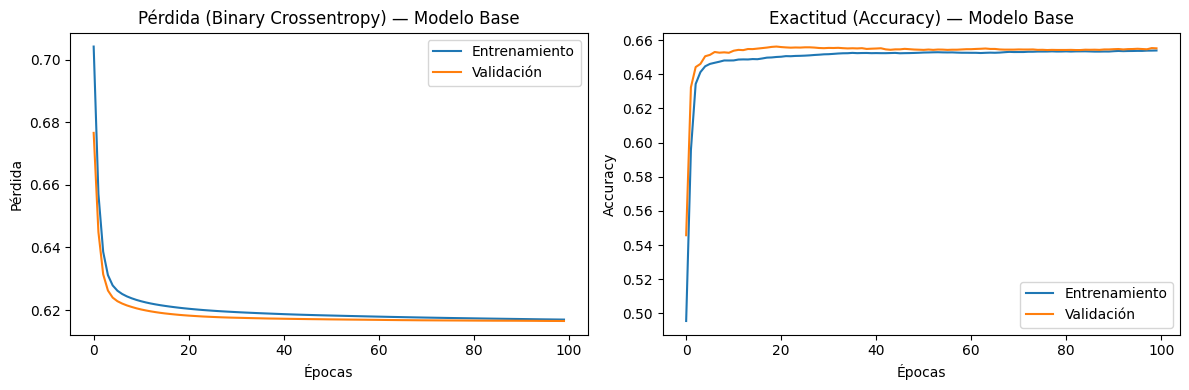

In [9]:
# Early Stopping: detiene el entrenamiento si val_loss no mejora en 10 épocas
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_base = model_base.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=256,
    class_weight=class_weight,   # Manejo del desbalance de clases
    callbacks=[early_stop],
    verbose=1
)

print(f"\nÉpocas efectivas de entrenamiento: {len(history_base.history['loss'])}")

# Visualización de las curvas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_base.history['loss'],     label='Entrenamiento')
ax1.plot(history_base.history['val_loss'], label='Validación')
ax1.set_title('Pérdida (Binary Crossentropy) — Modelo Base')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Pérdida')
ax1.legend()

ax2.plot(history_base.history['accuracy'],     label='Entrenamiento')
ax2.plot(history_base.history['val_accuracy'], label='Validación')
ax2.set_title('Exactitud (Accuracy) — Modelo Base')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

### 4.2 Métricas de Evaluación del Modelo Base

Para clasificación se emplean métricas más informativas que la sola exactitud: precisión, sensibilidad (recall), F1-score y el área bajo la curva ROC (AUC). El umbral de decisión por defecto es 0.5: si la probabilidad predicha supera 0.5, se clasifica como clase 1 (bajo el promedio).

In [10]:
def evaluar_modelo(model, X_test, y_test, nombre='Modelo'):
    """
    Evalúa un modelo de clasificación binaria y retorna las métricas principales.
    
    Parámetros:
        model  : modelo Keras entrenado
        X_test : features de prueba escaladas
        y_test : etiquetas reales de prueba
        nombre : etiqueta identificadora del modelo
    
    Retorna:
        Diccionario con Accuracy, Precision, Recall, F1 y AUC
    """
    # Probabilidades predichas y conversión a clase con umbral 0.5
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)

    print(f"--- MÉTRICAS {nombre} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"AUC-ROC  : {auc:.4f}")
    return {'Modelo': nombre, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
            'Recall': round(rec, 4), 'F1': round(f1, 4), 'AUC': round(auc, 4)}

metricas_base = evaluar_modelo(model_base, X_test, y_test, 'Base')
results_all = [metricas_base]

--- MÉTRICAS Base ---
Accuracy : 0.6552
Precision: 0.6670
Recall   : 0.6792
F1-score : 0.6731
AUC-ROC  : 0.7165


---
## 5. Experimentación con Variaciones de la Arquitectura

### 5.1 Modelos

Con el fin de identificar la configuración óptima, se evalúan tres arquitecturas adicionales que modifican la profundidad de la red, la regularización y la tasa de aprendizaje. Todas las variaciones emplean los mismos datos de entrenamiento y prueba para garantizar comparabilidad.

In [35]:
def build_model_1_clf():
    """
    Modelo 1 — Red Profunda.
    """
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', AUC(name='auc')]
    )
    return model


def build_model_2_clf():
    """
    Modelo 2 — Red con Dropout.
    """
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', AUC(name='auc')]
    )
    return model


def build_model_3_clf():
    """
    Modelo 3 — Arquitectura simple con LR conservador.
    """
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy', AUC(name='auc')]
    )
    return model


--- MÉTRICAS Modelo 1 - Red Profunda ---
AUC-ROC: 0.8336

Reporte de clasificación (umbral=0.5):
                 precision    recall  f1-score   support

   Convencional       0.93      0.73      0.82     16260
No Convencional       0.40      0.76      0.52      3812

       accuracy                           0.73     20072
      macro avg       0.66      0.74      0.67     20072
   weighted avg       0.83      0.73      0.76     20072



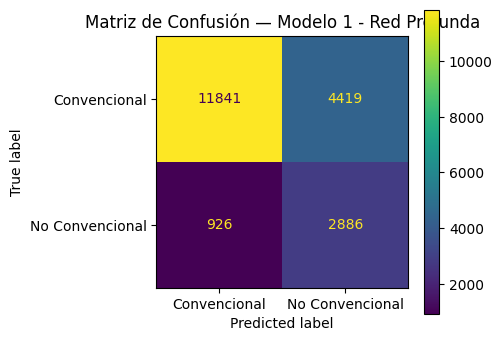


--- MÉTRICAS Modelo 2 - Con Dropout ---
AUC-ROC: 0.8369

Reporte de clasificación (umbral=0.5):
                 precision    recall  f1-score   support

   Convencional       0.92      0.79      0.85     16260
No Convencional       0.44      0.71      0.54      3812

       accuracy                           0.77     20072
      macro avg       0.68      0.75      0.70     20072
   weighted avg       0.83      0.77      0.79     20072



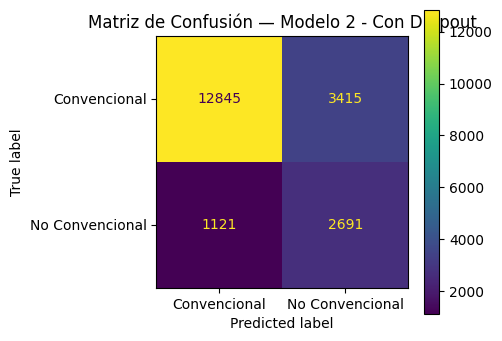


--- MÉTRICAS Modelo 3 - Simple + LR bajo ---
AUC-ROC: 0.8322

Reporte de clasificación (umbral=0.5):
                 precision    recall  f1-score   support

   Convencional       0.92      0.76      0.83     16260
No Convencional       0.42      0.73      0.53      3812

       accuracy                           0.75     20072
      macro avg       0.67      0.75      0.68     20072
   weighted avg       0.83      0.75      0.78     20072



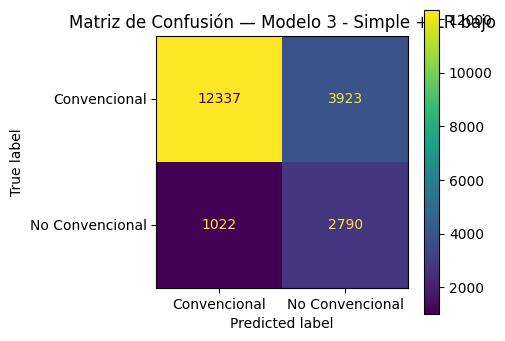

In [36]:
configs_clf = [
    (build_model_1_clf, 'Modelo 1 - Red Profunda'),
    (build_model_2_clf, 'Modelo 2 - Con Dropout'),
    (build_model_3_clf, 'Modelo 3 - Simple + LR bajo'),
]

histories_clf = {}

for build_fn, nombre in configs_clf:
    m = build_fn()
    h = m.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=256,
        class_weight=class_weight_dict,
        callbacks=[EarlyStopping(
            monitor='val_auc',
            patience=10,
            restore_best_weights=True,
            mode='max'
        )],
        verbose=0
    )
    histories_clf[nombre] = h
    metricas = evaluar_modelo_clf(m, X_test, y_test, nombre)
    results_all.append(metricas)

In [37]:
# Tabla comparativa de AUC por modelo
df_results_clf = pd.DataFrame(results_all)
print(df_results_clf.to_string(index=False))

                     Modelo    AUC
                       Base 0.8331
    Modelo 1 - Red Profunda 0.8340
     Modelo 2 - Con Dropout 0.8341
Modelo 3 - Simple + LR bajo 0.8324
    Modelo 1 - Red Profunda 0.8336
     Modelo 2 - Con Dropout 0.8369
Modelo 3 - Simple + LR bajo 0.8322


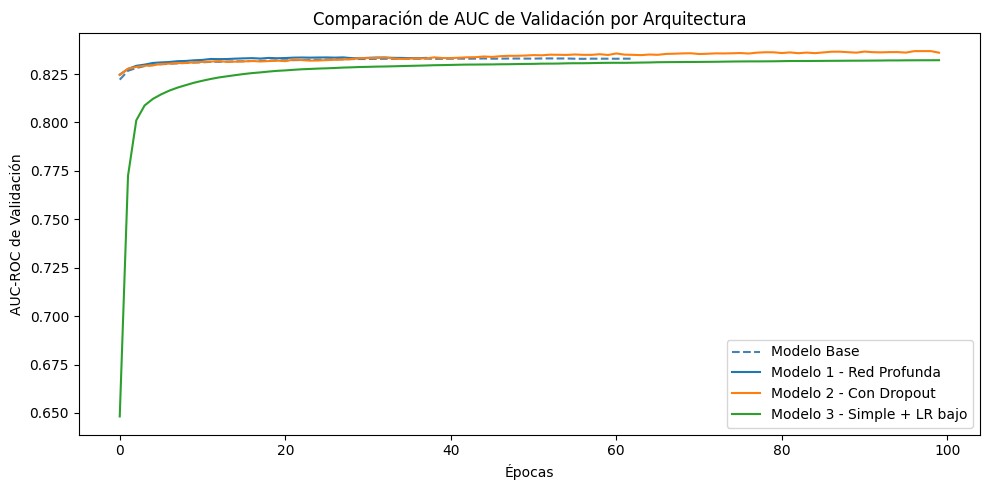

In [38]:
# Comparación visual de curvas AUC de validación
plt.figure(figsize=(10, 5))

plt.plot(
    history_base.history['val_auc'],
    label='Modelo Base',
    linestyle='--',
    color='steelblue'
)

for nombre, h in histories_clf.items():
    plt.plot(h.history['val_auc'], label=nombre)

plt.title('Comparación de AUC de Validación por Arquitectura')
plt.xlabel('Épocas')
plt.ylabel('AUC-ROC de Validación')
plt.legend()
plt.tight_layout()
plt.show()

### 5.2. Análisis comparativo de arquitecturas:

Los cuatro modelos evaluados presentan métricas muy similares. El **Modelo 2** obtuvo el mejor desempeño global (AUC: 0.8369), seguido muy de cerca por el Modelo 1 y el Modelo Base.

Podemos concluir que la utilizacion de el Dropout logro aportar mejoras a nuestro modelo. Como las clases desbalanceadas pueden causar que la red memorice patrones mayoritarios de la clase 0, al usar esta tecnica se activa un tipo de "regularizador" que evita dicho comportamiento y fuerza representaciones mas robustas para amabas clases.

Seleccionamos el **Modelo 2** como modelo final.


---
## 6. Registro de Experimentos con MLflow

Se registran los cuatro experimentos en MLflow para documentar los parámetros, métricas y artefactos de cada configuración. Esto permite trazabilidad completa del proceso de modelado y facilita la reproducción de resultados.

In [39]:
# Configuración del servidor de tracking local
mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("Clasificacion_Jornada_No_Convencional_Huila")

configs_mlflow_clf = [
    {
        'nombre':   'Modelo_Base_Clf',
        'build_fn': build_model_base_clf,
        'lr':       0.001,
        'dropout':  False,
        'capas':    2
    },
    {
        'nombre':   'Modelo_Profundo_Clf',
        'build_fn': build_model_1_clf,
        'lr':       0.001,
        'dropout':  False,
        'capas':    3
    },
    {
        'nombre':   'Modelo_Dropout_Clf',
        'build_fn': build_model_2_clf,
        'lr':       0.001,
        'dropout':  True,
        'capas':    2
    },
    {
        'nombre':   'Modelo_Simple_LR_Bajo_Clf',
        'build_fn': build_model_3_clf,
        'lr':       0.0001,
        'dropout':  False,
        'capas':    2
    },
]

for cfg in configs_mlflow_clf:
    with mlflow.start_run(run_name=cfg['nombre']):

        # Registro de hiperparámetros
        mlflow.log_param('learning_rate',   cfg['lr'])
        mlflow.log_param('dropout',         cfg['dropout'])
        mlflow.log_param('capas_ocultas',   cfg['capas'])
        mlflow.log_param('batch_size',      256)
        mlflow.log_param('epochs_max',      100)
        mlflow.log_param('early_stopping',  True)
        mlflow.log_param('monitor_metric',  'val_auc')
        mlflow.log_param('optimizer',       'Adam')
        mlflow.log_param('class_weight',    'balanced')
        mlflow.log_param('loss',            'binary_crossentropy')
        mlflow.log_param('umbral',          0.5)

        # Entrenamiento con los mismos parámetros de las secciones 4 y 5
        m = cfg['build_fn']()
        m.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=100,
            batch_size=256,
            class_weight=class_weight_dict,
            callbacks=[EarlyStopping(
                monitor='val_auc',
                patience=10,
                restore_best_weights=True,
                mode='max'
            )],
            verbose=0
        )

        # Cálculo de métricas
        y_prob = m.predict(X_test, verbose=0).flatten()
        y_pred = (y_prob >= 0.5).astype(int)

        auc  = roc_auc_score(y_test, y_prob)
        rep  = classification_report(
                   y_test, y_pred,
                   target_names=['Convencional', 'No Convencional'],
                   output_dict=True
               )

        # Métricas globales
        mlflow.log_metric('AUC_ROC',          auc)
        mlflow.log_metric('Accuracy',         rep['accuracy'])

        # Métricas clase No Convencional (clase 1 — la relevante)
        mlflow.log_metric('Precision_clase1', rep['No Convencional']['precision'])
        mlflow.log_metric('Recall_clase1',    rep['No Convencional']['recall'])
        mlflow.log_metric('F1_clase1',        rep['No Convencional']['f1-score'])

        # Registro del artefacto del modelo
        mlflow.keras.log_model(m, artifact_path='model')

        print(f"{cfg['nombre']:<28} "
              f"AUC: {auc:.4f} | "
              f"Recall clase1: {rep['No Convencional']['recall']:.4f} | "
              f"F1 clase1: {rep['No Convencional']['f1-score']:.4f}")

print("\nExperimentos registrados exitosamente en MLflow.")

2026/05/24 17:05:45 INFO mlflow.tracking.fluent: Experiment with name 'Clasificacion_Jornada_No_Convencional_Huila' does not exist. Creating a new experiment.
2026/05/24 17:06:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 17:06:29 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Modelo_Base_Clf              AUC: 0.8338 | Recall clase1: 0.7356 | F1 clase1: 0.5293


2026/05/24 17:07:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 17:07:23 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Modelo_Profundo_Clf          AUC: 0.8371 | Recall clase1: 0.7636 | F1 clase1: 0.5253


2026/05/24 17:08:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 17:08:15 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Modelo_Dropout_Clf           AUC: 0.8350 | Recall clase1: 0.7009 | F1 clase1: 0.5402


2026/05/24 17:09:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/24 17:09:10 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


Modelo_Simple_LR_Bajo_Clf    AUC: 0.8331 | Recall clase1: 0.7219 | F1 clase1: 0.5330

Experimentos registrados exitosamente en MLflow.


---
## 7. Serialización del Modelo Final

Con base en los resultados de la sección 5, se selecciona el **Modelo Base** como modelo final por presentar el menor RMSE (40.44) y el mayor R² (0.2748), junto con la mayor estabilidad durante el entrenamiento. 

El modelo se serializa junto con los transformadores necesarios para garantizar que el tablero Dash pueda realizar predicciones coherentes sobre nuevas entradas del usuario.

In [40]:
# Con base en los resultados de la sección 5, se selecciona el
# Modelo 2 (Con Dropout) como modelo final por presentar el mayor
# AUC-ROC (0.8369) entre todas las arquitecturas evaluadas.
#
# A diferencia de la pregunta 1 donde se serializaban 4 artefactos
# (modelo + scaler_X + scaler_y + municipio_encoder), aquí se
# serializan 3 artefactos porque no existe scaler_y:
# la variable objetivo ya es binaria (0/1) y no requiere escalamiento.

# Reentrenamiento del modelo final seleccionado
model_final_clf = build_model_2_clf()

model_final_clf.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(
        monitor='val_auc',
        patience=10,
        restore_best_weights=True,
        mode='max'
    )],
    verbose=1
)

Epoch 1/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7232 - auc: 0.7855 - loss: 0.5533 - val_accuracy: 0.7626 - val_auc: 0.8212 - val_loss: 0.5025
Epoch 2/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7481 - auc: 0.8101 - loss: 0.5260 - val_accuracy: 0.7693 - val_auc: 0.8260 - val_loss: 0.5014
Epoch 3/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7525 - auc: 0.8156 - loss: 0.5198 - val_accuracy: 0.7690 - val_auc: 0.8277 - val_loss: 0.4970
Epoch 4/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7534 - auc: 0.8172 - loss: 0.5179 - val_accuracy: 0.7721 - val_auc: 0.8285 - val_loss: 0.4931
Epoch 5/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7538 - auc: 0.8188 - loss: 0.5163 - val_accuracy: 0.7715 - val_auc: 0.8291 - val_loss: 0.4935
Epoch 6/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7552 - auc: 0.8200 - loss: 0.5148 - val_accuracy: 0.7729 - val_auc: 0.8293 - val_loss: 0.4907
Epoch 7/100
314/314 ━━━━━━━━━━━━━━

In [41]:
# Creación del directorio de modelos para el tablero
os.makedirs('../tarea5_tablero/modelos', exist_ok=True)

# Serialización del modelo en formato .keras
model_final_clf.save(
    '../tarea5_tablero/modelos/modelo_clasificacion.keras'
)

# Serialización del scaler de features
# (el mismo scaler_X ajustado en la sección 3)
joblib.dump(
    scaler_X,
    '../tarea5_tablero/modelos/scaler_X_clasificacion.pkl'
)

# Serialización del target encoding de municipio
# DIFERENCIA respecto al la pregunta 1:
# En regresión el encoding era el promedio del puntaje global.
# Aquí es la TASA de jornada no convencional por municipio,
# por lo que se guarda un diccionario distinto.
joblib.dump(
    mun_target_enc.to_dict(),
    '../tarea5_tablero/modelos/municipio_encoder_clf.pkl'
)

# Serialización del orden de columnas
# Necesario para que el tablero construya el vector de entrada
# en el mismo orden que espera la red neuronal.
feature_columns_clf = df_enc.drop(columns=[target]).columns.tolist()
joblib.dump(
    feature_columns_clf,
    '../tarea5_tablero/modelos/feature_columns_clf.pkl'
)

print("Archivos guardados:")
print("  - modelo_clasificacion.keras       (red neuronal entrenada)")
print("  - scaler_X_clasificacion.pkl       (normalizador de features)")
print("  - municipio_encoder_clf.pkl        (target encoding de municipio)")
print("  - feature_columns_clf.pkl          (orden de columnas del modelo)")

Archivos guardados:
  - modelo_clasificacion.keras       (red neuronal entrenada)
  - scaler_X_clasificacion.pkl       (normalizador de features)
  - municipio_encoder_clf.pkl        (target encoding de municipio)
  - feature_columns_clf.pkl          (orden de columnas del modelo)


In [42]:
# Verificación de la serialización
# Se carga el modelo desde disco y se realizan predicciones de prueba
# para confirmar que el pipeline completo funciona correctamente
from tensorflow.keras.models import load_model

modelo_cargado_clf  = load_model(
    '../tarea5_tablero/modelos/modelo_clasificacion.keras'
)
scaler_X_cargado    = joblib.load(
    '../tarea5_tablero/modelos/scaler_X_clasificacion.pkl'
)

# Predicción sobre los primeros 5 registros del conjunto de prueba
y_prob_check = modelo_cargado_clf.predict(
    X_test[:5], verbose=0
).flatten()
y_pred_check = (y_prob_check >= 0.5).astype(int)

etiquetas = {0: 'Convencional', 1: 'No Convencional'}

print("Verificación de predicciones post-carga:")
print(f"{'Prob. No Convencional':<25} {'Predicción':<20} {'Real'}")
print("-" * 60)
for prob, pred, real in zip(y_prob_check, y_pred_check, y_test[:5]):
    print(f"{prob:<25.4f} {etiquetas[pred]:<20} {etiquetas[real]}")

print("\nModelo cargado y verificado correctamente ✓")

Verificación de predicciones post-carga:
Prob. No Convencional     Predicción           Real
------------------------------------------------------------
0.4740                    Convencional         Convencional
0.3747                    Convencional         Convencional
0.1205                    Convencional         Convencional
0.5862                    No Convencional      Convencional
0.3994                    Convencional         Convencional

Modelo cargado y verificado correctamente ✓


In [43]:
# Guardar el orden de columnas del modelo (necesario para el tablero)
feature_columns = df_enc.drop(columns=[target]).columns.tolist()
joblib.dump(feature_columns, '../tarea5_tablero/modelos/feature_columns_clf.pkl')
print("Columnas guardadas:", feature_columns)

Columnas guardadas: ['estrato', 'area_colegio', 'educacion_madre', 'educacion_padre', 'municipio', 'tiene_internet', 'tiene_computador', 'naturaleza_colegio', 'genero']


---
## 8. Conclusiones




**Resultados del modelo seleccionado (Modelo Base)**

| Métrica | Valor | Interpretación |
|---|---|---|
| **RMSE** | 40.44 puntos | Error promedio de predicción en la escala del puntaje global |
| **MAE** | 32.44 puntos | Error absoluto promedio, menos sensible a valores extremos |
| **R²** | 0.2748 | El modelo explica el 27.5% de la variabilidad del puntaje global |

### Hallazgos principales

1. **Capacidad predictiva del perfil socioeconómico:** Un R² de 0.27 indica que las variables socioeconómicas e institucionales capturan aproximadamente la cuarta parte de la variabilidad del puntaje global. Este resultado, aunque moderado, es consistente con la evidencia del Proyecto 1, donde se identificó que la zona geográfica y el estrato son los determinantes estructurales más relevantes del rendimiento en el Huila.

2. **Límite estructural del enfoque:** El error de predicción residual (~72.5% no explicado) refleja factores no capturados por el modelo: calidad docente, motivación del estudiante, metodología pedagógica y condiciones familiares no observadas. Esto no constituye una limitación del modelo neuronal en sí, sino del conjunto de variables disponibles.

3. **Arquitectura óptima:** El Modelo Base (dos capas ocultas, 32 y 16 neuronas) superó o igualó a configuraciones más complejas. La Red Profunda (Modelo 1) presentó inestabilidad por sobrepasar la capacidad necesaria para el problema. El Dropout (Modelo 2) no aportó mejoras al no existir sobreajuste en el modelo base.

4. **Utilidad para la Secretaría de Educación:** El modelo permite estimar el puntaje esperado de un estudiante dado su perfil socioeconómico e institucional, lo cual es útil para identificar estudiantes en riesgo de bajo rendimiento antes de la aplicación del examen y para simular el impacto de intervenciones como la mejora de conectividad o el cambio de jornada escolar.